In [9]:
import pandas as pd


""" want to predict how much medals a team will win in the olympics using a linear regression model."""
""" y will be medals"""

# https://www.youtube.com/watch?v=Hr06nSA-qww&list=PLeh6bTovBTM7MbSDb8Xo7GGOA1kWVAG8C&index=6
df = pd.read_csv('teams.csv')

df.head()


,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
0,AFG,Afghanistan,1964,8,8,22.0,161.0,64.2,0,0.0,0.0
1,AFG,Afghanistan,1968,5,5,23.2,170.2,70.0,0,0.0,0.0
2,AFG,Afghanistan,1972,8,8,29.0,168.3,63.8,0,0.0,0.0
3,AFG,Afghanistan,1980,11,11,23.6,168.4,63.2,0,0.0,0.0
4,AFG,Afghanistan,2004,5,5,18.6,170.8,64.8,0,0.0,0.0


In [10]:
df = df.drop(columns=['events','height','weight', 'prev_3_medals']) # won't be needing these

In [11]:
df = df.rename({'age': 'avg_age'}, axis=1) # give it a more accurate name
df

,team,country,year,athletes,avg_age,medals,prev_medals
0,AFG,Afghanistan,1964,8,22.0,0,0.0
1,AFG,Afghanistan,1968,5,23.2,0,0.0
2,AFG,Afghanistan,1972,8,29.0,0,0.0
3,AFG,Afghanistan,1980,11,23.6,0,0.0
4,AFG,Afghanistan,2004,5,18.6,0,0.0
...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,26,25.0,0,0.0
2140,ZIM,Zimbabwe,2004,14,25.1,3,0.0
2141,ZIM,Zimbabwe,2008,16,26.1,4,3.0
2142,ZIM,Zimbabwe,2012,9,27.3,0,4.0


In [12]:
# let's see how the medals column (the target column) is corrrelated to the features
df.select_dtypes(include=['number']).corr()['medals']

year          -0.021603
athletes       0.840817
avg_age        0.025096
medals         1.000000
prev_medals    0.920048
Name: medals, dtype: float64

In [13]:
# it looks like it has a strong corellation with athletes and prev_medals. lets plot it first

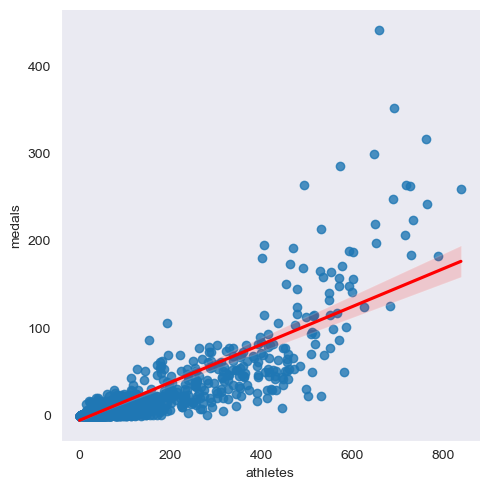

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("dark")

sns.lmplot(x='athletes', y='medals', data=df, fit_reg=True, line_kws={'color': 'red'})

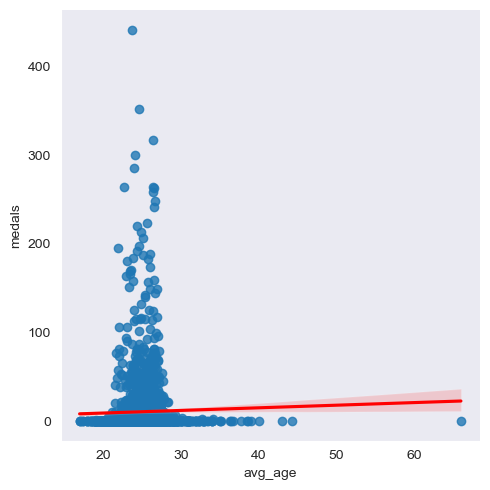

In [15]:
#age has a weak correlation with medals. let's still look at it

sns.lmplot(x='avg_age', y='medals', data=df, fit_reg=True, line_kws={'color': 'red'})

<Axes: ylabel='Frequency'>

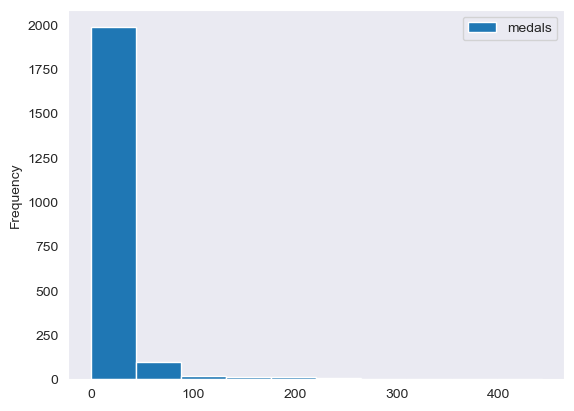

In [16]:

# since the column we are trying to predict is medals, let's first see its distribution
# we can see that most countries have 0-50 medals, will the very few rest rest have more

df.plot.hist(y='medals')

In [17]:
# let's see how many medals each country has along with number of appearances

df.groupby('team').agg(
    total_medals=('medals', 'sum'),
    appearances=('medals', 'count')
).sort_values(by='total_medals', ascending=False)


,total_medals,appearances
team,,
USA,3046,13
URS,1608,6
AUS,1112,14
GER,1057,8
CHN,909,9
...,...,...
GBS,0,6
GEQ,0,9
OMA,0,9


<strong>LET'S SEE MISSING VALUES

In [56]:
df.isnull().any() 

team           False
country        False
year           False
athletes       False
avg_age        False
medals         False
prev_medals     True
dtype: bool

In [54]:
# only prev_medals has missing values
df[df.isnull().any(axis=1)]

,team,country,year,athletes,avg_age,medals,prev_medals
19,ALB,Albania,1992,9,25.3,0,NaN
26,ALG,Algeria,1964,7,26.0,0,NaN
39,AND,Andorra,1976,3,28.3,0,NaN
50,ANG,Angola,1980,17,17.4,0,NaN
59,ANT,Antigua and Barbuda,1976,17,23.2,0,NaN
...,...,...,...,...,...,...,...
2092,VIN,Saint Vincent and the Grenadines,1988,6,20.5,0,NaN
2103,YAR,North Yemen,1984,3,27.7,0,NaN
2105,YEM,Yemen,1992,8,19.6,0,NaN
2112,YMD,South Yemen,1988,5,23.6,0,NaN


In [58]:
df = df.dropna()
df

,team,country,year,athletes,avg_age,medals,prev_medals
0,AFG,Afghanistan,1964,8,22.0,0,0.0
1,AFG,Afghanistan,1968,5,23.2,0,0.0
2,AFG,Afghanistan,1972,8,29.0,0,0.0
3,AFG,Afghanistan,1980,11,23.6,0,0.0
4,AFG,Afghanistan,2004,5,18.6,0,0.0
...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,26,25.0,0,0.0
2140,ZIM,Zimbabwe,2004,14,25.1,3,0.0
2141,ZIM,Zimbabwe,2008,16,26.1,4,3.0
2142,ZIM,Zimbabwe,2012,9,27.3,0,4.0


<strong> Building the model

Since this is Times Series data, we will make the last two years (2012 & 2016) for the test data
can't use future data to predict past data. that's data leakage
so we will use the years before 2012 as training data, then predict using 2012 and 2016 data

In [61]:
train = df[df['year'] < 2012].copy()
test = df[df['year'] >= 2012].copy()

In [63]:
train.shape, test.shape

((1609, 7), (405, 7))

In [65]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

predictors = ['athletes', 'prev_medals']
target = 'medals'
X_train = train[predictors]
y_train = train[target]
X_test = test[predictors]
y_test = test[target]

In [67]:
model.fit(X_train, y_train)

LinearRegression()

In [69]:
predictions = model.predict(X_test)

In [71]:
predictions

array([-9.61221245e-01, -1.17633261e+00, -1.42503158e+00, -1.71184673e+00,
        2.15562926e+00,  3.91463636e+00, -1.71184673e+00, -1.85525431e+00,
        3.67563128e-01, -2.77770967e-01, -1.85525431e+00, -1.49673537e+00,
        4.67519911e+01,  2.87550937e+01,  4.58450091e+00,  2.54773581e+00,
       -1.85525431e+00, -1.64014295e+00, -1.85525431e+00, -1.85525431e+00,
        1.46556876e+02,  1.20571799e+02,  6.56314795e+00,  3.95275254e+00,
        7.34283247e+00,  1.03117468e+01,  5.19171882e+00,  3.58517645e+00,
       -1.64014295e+00, -1.64014295e+00, -1.56843916e+00, -1.20992022e+00,
       -1.71184673e+00, -1.42503158e+00,  1.17929959e+01,  1.00049298e+01,
       -1.78355052e+00, -1.71184673e+00, -1.56843916e+00, -1.56843916e+00,
       -1.99866189e+00, -1.99866189e+00, -1.56843916e+00, -1.35332779e+00,
       -1.92695810e+00, -1.92695810e+00,  3.28912706e+01,  2.53042547e+01,
       -1.78355052e+00, -1.28162400e+00, -1.85525431e+00, -3.87590939e-01,
        7.83480779e+01,  

<strong> Some predictions are less than 0, and they're all float values.
The model is supposed to predict number of medals a country will win. 
So we can manually correct this:

In [74]:
test['predictions'] = predictions
test

,team,country,year,athletes,avg_age,medals,prev_medals,predictions
6,AFG,Afghanistan,2012,6,24.8,1,1.0,-0.961221
7,AFG,Afghanistan,2016,3,24.7,0,1.0,-1.176333
24,ALB,Albania,2012,10,25.7,0,0.0,-1.425032
25,ALB,Albania,2016,6,23.7,0,0.0,-1.711847
37,ALG,Algeria,2012,39,24.8,1,2.0,2.155629
...,...,...,...,...,...,...,...,...
2111,YEM,Yemen,2016,3,19.3,0,0.0,-1.926958
2131,ZAM,Zambia,2012,7,22.6,0,0.0,-1.640143
2132,ZAM,Zambia,2016,7,24.1,0,0.0,-1.640143
2142,ZIM,Zimbabwe,2012,9,27.3,0,4.0,1.505767


In [78]:
test.loc[test['predictions'] < 0, 'predictions'] = 0
test['predictions'] = test['predictions'].round()

test

,team,country,year,athletes,avg_age,medals,prev_medals,predictions
6,AFG,Afghanistan,2012,6,24.8,1,1.0,0.0
7,AFG,Afghanistan,2016,3,24.7,0,1.0,0.0
24,ALB,Albania,2012,10,25.7,0,0.0,0.0
25,ALB,Albania,2016,6,23.7,0,0.0,0.0
37,ALG,Algeria,2012,39,24.8,1,2.0,2.0
...,...,...,...,...,...,...,...,...
2111,YEM,Yemen,2016,3,19.3,0,0.0,0.0
2131,ZAM,Zambia,2012,7,22.6,0,0.0,0.0
2132,ZAM,Zambia,2016,7,24.1,0,0.0,0.0
2142,ZIM,Zimbabwe,2012,9,27.3,0,4.0,2.0


<strong> Now let's evaluate the model using MAE

In [81]:
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(test['medals'], test['predictions'])

error

3.2987654320987656

<strong> this means on average the model was 3 medals off the actual value.


but whether this is good or not, let's find out

In [84]:
df.medals.describe()

count    2014.000000
mean       10.990070
std        33.627528
min         0.000000
25%         0.000000
50%         0.000000
75%         5.000000
max       442.000000
Name: medals, dtype: float64

<strong> the error of 3 is well below the standard deviation which is good

let's look at some teams

In [96]:
test.loc[test.team == 'USA']

,team,country,year,athletes,avg_age,medals,prev_medals,predictions
2053,USA,United States,2012,689,26.7,248,317.0,285.0
2054,USA,United States,2016,719,26.4,264,248.0,236.0


In [98]:
test.loc[test.team == 'IND']

,team,country,year,athletes,avg_age,medals,prev_medals,predictions
907,IND,India,2012,95,26.0,6,3.0,7.0
908,IND,India,2016,130,26.1,2,6.0,12.0


<strong> For the USA, being off by 40 (248 - 285) is a smaller percentage of error than India's error of 2 to 12

In [111]:
errors = (test.medals - test.predictions).abs()
errors

6       1.0
7       0.0
24      0.0
25      0.0
37      1.0
       ... 
2111    0.0
2131    0.0
2132    0.0
2142    2.0
2143    0.0
Length: 405, dtype: float64

In [119]:
error_by_team = errors.groupby(test ["team"]).mean()
error_by_team

team
AFG    0.5
ALB    0.0
ALG    1.5
AND    0.0
ANG    0.0
      ... 
VIE    1.0
VIN    0.0
YEM    0.0
ZAM    0.0
ZIM    1.0
Length: 204, dtype: float64